# Image Preprocessing and Data Augmentation Visualizations

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import sys

In [2]:
# Mount Google Drive for CBIS-DDSM Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Clone the github repository with source code
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 400, done.
remote: Counting objects: 100% (178/178), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 400 (delta 63), reused 104 (delta 34), pack-reused 222 (from 1)
Receiving objects: 100% (400/400), 15.24 MiB | 18.63 MiB/s, done.
Resolving deltas: 100% (168/168), done.
/content/CM3070_Final_Project


In [4]:
# Add path to the repository code in this notebook
sys.path.append('/content/CM3070_Final_Project')

In [5]:
# Import image preprocessing pipeline functions from source code repository
from src.image_preprocessing.image_preprocessing_pipelines import *
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.dataset.dataset import *
from src.dataset.data_augmentation import *
from src.utils import *

In [6]:
# Unzip and extract validation dataset from drive to the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"

In [7]:
# Load the validation data metadata CSV from the drive
val_df = pd.read_csv('/content/drive/MyDrive/CBISDDSM/val_data.csv')

In [8]:
# Update 'image_path' of all dataframes with new image path source
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)

## Original Image Sample

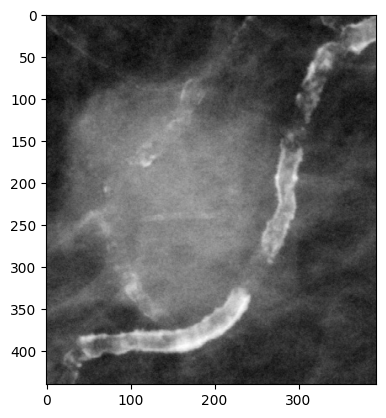

In [9]:
sample_image = plt.imread(val_df['new_image_path'][10])
plt.imshow(sample_image, cmap="gray")

## Image Preprocessing Pipelines

### CLAHE + Median Blur

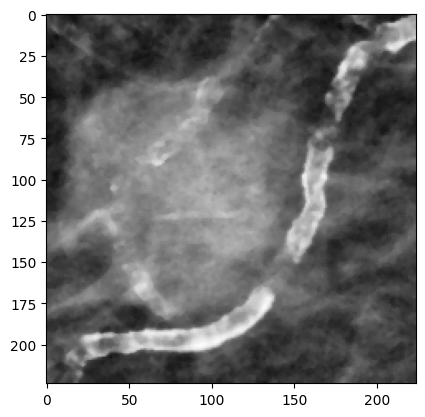

In [10]:
clahe_median_blur_image = clahe_median_blur_preprocessing(val_df['new_image_path'][10])
clahe_median_blur_image = clahe_median_blur_image / 255.0
plt.imshow(clahe_median_blur_image, cmap="gray")

### Histogram Equalization + Gaussian Blur

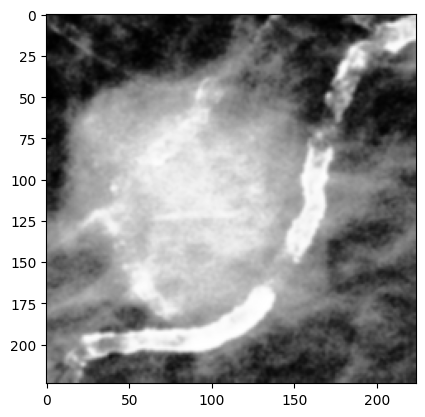

In [11]:
histo_equalized_gauss_blur_image = histogram_equalization_gaussian_blur_preprocessing(val_df['new_image_path'][10])
plt.imshow(histo_equalized_gauss_blur_image, cmap="gray")

## Data Augmentation

In [12]:
preprocessor = IMAGE_PREPROCESSORS['baseline']

In [13]:
# Validation dataset
val_dataset = generate_dataset(val_df, preprocessor)

# Data Augmented Validation dataset
val_augmented_dataset = data_augmented_dataset(val_dataset)

# Data Augmented + Batched validation Dataset
augmented_batched_dataset = batch_dataset(val_augmented_dataset, 32)

# No data augmentation + Batched validation dataset
unaugmented_batched_dataset = batch_dataset(val_dataset, 32)

#### Visualize Original 10 Image Samples

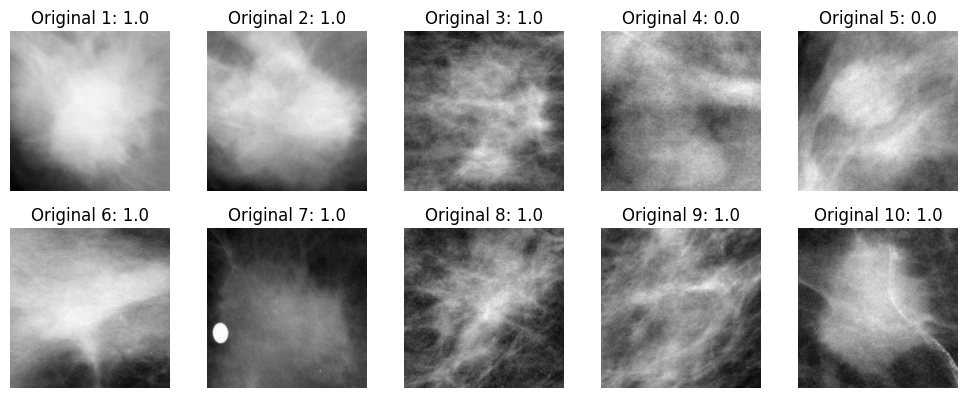

In [14]:
# Get the first batch from unaugmented batched dataset
for batch_image, batch_label in unaugmented_batched_dataset.take(1):
  plt.figure(figsize=(10, 10))

  # Display first 10 images of the selected batch
  for i in range(10):
    image = batch_image[i].numpy()
    pathology = batch_label[i]

    axes = plt.subplot(5, 5, i + 1)
    image = image / 255.0

    plt.imshow(image)
    plt.title(f"Original {i + 1}: {pathology}")
    plt.axis("off")

  plt.tight_layout()
  plt.show()

#### Visualize Data Augmented 10 Image Samples

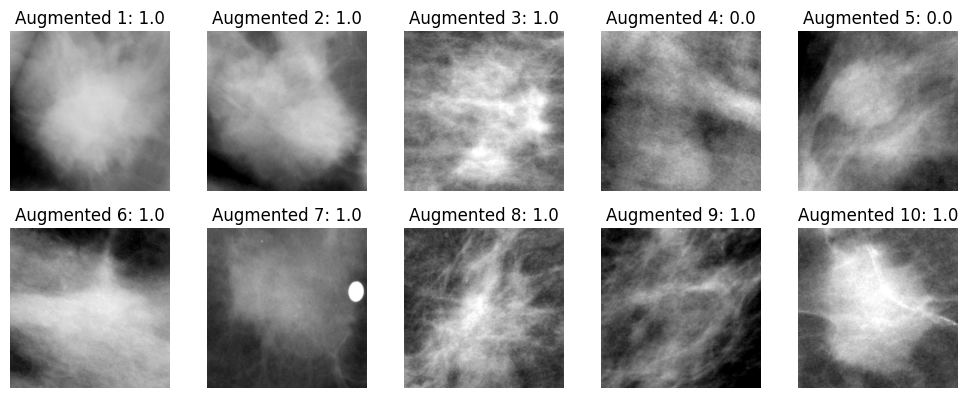

In [15]:
# Get the first batch of data augmented and batched dataset
for batch_image, batch_label in augmented_batched_dataset.take(1):
  plt.figure(figsize=(10, 10))

  # Display the first 10 data augmented image samples from the selected batch
  for i in range(10):
    image = batch_image[i].numpy()
    pathology = batch_label[i]

    axes = plt.subplot(5, 5, i + 1)
    image = image / 255.0

    plt.imshow(image)
    plt.title(f"Augmented {i + 1}: {pathology}")
    plt.axis("off")

  plt.tight_layout()
  plt.show()